Imports & Setups

In [1]:
import os
import yaml
from uuid import uuid1
from typing import List
from pathlib import Path
from termcolor import colored
from dotenv import load_dotenv
from langsmith import traceable
from rich.markdown import Markdown
from pydantic import BaseModel, Field
from langgraph.store.base import BaseStore
from langgraph.store.postgres import PostgresStore
from langchain_core.runnables import RunnableConfig
from langchain_core.prompts import ChatPromptTemplate
from langgraph.checkpoint.postgres import PostgresSaver
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph_utils import console, get_config, display_conversation

load_dotenv()
PARAMS_CONFIGS = yaml.safe_load(Path("configs/params.yaml").read_text())
PROMPTS_CONFIGS = yaml.safe_load(Path("configs/prompts.yaml").read_text())
DB_URI = PARAMS_CONFIGS["DB_URI"]

os.environ["LANGSMITH_PROJECT"] = "ltm_postgres"
os.environ["LANGCHAIN_TRACING_V2"] = "true"

Model & Parser

In [2]:
model = ChatGoogleGenerativeAI(**PARAMS_CONFIGS["llm"])
parser = StrOutputParser()

Output Schemas

In [3]:
class MemorySchema(BaseModel):
    key: str = Field(description=PARAMS_CONFIGS["MemorySchema"]["key"])
    value: str = Field(description=PARAMS_CONFIGS["MemorySchema"]["value"])


class DecisionSchema(BaseModel):
    update_memory: bool = Field(description=PARAMS_CONFIGS["DecisionSchema"]["update_memory"])
    memories: List[MemorySchema] = Field(description=PARAMS_CONFIGS["DecisionSchema"]["memories"])

#### Node & Utility Functions

In [4]:
def get_memories(namespace, store):
    items = store.search(namespace)
    if not items:
        return "No memories."

    return "\n".join(f"{item.key}: {item.value['text']}" for item in items)


def get_namespace(user_id):
    return ("user_id", user_id)

Chat Node Function

In [5]:
chat_prompt = ChatPromptTemplate(
    [
        ("system", PROMPTS_CONFIGS["chat"]["system"]),
        ("user", PROMPTS_CONFIGS["chat"]["user"]),
        ("placeholder", "{messages}"),
    ]
)
chat_chain = chat_prompt | model | parser


@traceable(name="chat")
def chat(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = get_namespace(user_id=user_id)
    current_memories = get_memories(namespace=namespace, store=store)

    res = chat_chain.invoke(
        {
            "current_memories": current_memories,
            "messages": state.get("messages", []),
        },
        config=config,
    )
    return {"messages": [AIMessage(content=res)]}


Memory Node Function

In [6]:
memory_prompt = ChatPromptTemplate(
    [
        ("system", PROMPTS_CONFIGS["memory"]["system"]),
        ("user", PROMPTS_CONFIGS["memory"]["user"]),
    ]
)

memory_model = model.with_structured_output(DecisionSchema)
memory_chain = memory_prompt | memory_model


@traceable(name="memory")
def memory(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = get_namespace(user_id=user_id)

    recent_message = next(message.content for message in reversed(state["messages"]) if isinstance(message, HumanMessage))

    current_memories = get_memories(namespace=namespace, store=store)

    res = memory_chain.invoke(
        {
            "current_memories": current_memories,
            "recent_message": recent_message,
        },
        config=config,
    )

    if res.update_memory:
        for memory in res.memories:
            store.put(
                namespace=namespace,
                key=memory.key,
                value={"text": memory.value},
            )

    return {}


Init Graph

In [7]:
graph = StateGraph(MessagesState)

Add Nodes

In [8]:
graph.add_node("chat", chat)
graph.add_node("memory", memory)


Add Edges

In [9]:
graph.add_edge(START, "memory")
graph.add_edge("memory", "chat")
graph.add_edge("chat", END)


Checkpointer

In [10]:
checkpointer_context_manager = PostgresSaver.from_conn_string(conn_string=DB_URI)
checkpointer = checkpointer_context_manager.__enter__()
checkpointer.setup()


Store

In [11]:
store_context_manager = PostgresStore.from_conn_string(conn_string=DB_URI)
store = store_context_manager.__enter__()
store.setup()


Compilation

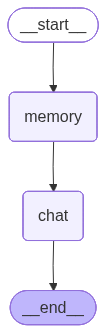

In [12]:
workflow = graph.compile(
    checkpointer=checkpointer,
    store=store,
)
workflow

Config

In [13]:
user_id, thread_id = "user_buh", "thread_buh"
config = get_config(user_id=user_id, thread_id=thread_id)

Execution

In [14]:
while True:
    user_input = input()
    if user_input.lower() in ["exit", "bye", "seeya", "goodbye"]:
        break

    final_state = workflow.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config=config,
    )

    recent_query = next(message for message in reversed(final_state["messages"]) if isinstance(message, HumanMessage))
    recent_response = next(message for message in reversed(final_state["messages"]) if isinstance(message, AIMessage))

    display_conversation(messages=[recent_query, recent_response])



Human:
i like winter season now                                                                                                
LLM:
Okay, buh, thanks for letting me know! So now, I understand you like the winter season.                                 

Human:
Without guessing, list every personal fact you know about me                                                            
LLM:
Okay, buh, here's a list of the personal facts I know about you without guessing:                                       

 • You work at Lumon Industries.                                                                                        
 • You like the winter season.                                                                                          
 • You like garlic guajillo shrimps.                                                                                    
 • You prefer to be referenced as buh.                                                                                  
 • We

In [15]:
store_context_manager.__exit__(None, None, None)
checkpointer_context_manager.__exit__(None, None, None)

False

Retrive Conversations

In [16]:
with PostgresSaver.from_conn_string(DB_URI) as checkpointer:
    workflow = graph.compile(checkpointer=checkpointer)
    states = workflow.get_state(config=config)

messages = states.values["messages"]
display_conversation(messages=messages)



Human:
reference me as buh                                                                                                     
LLM:
Okay, I'll be sure to reference you as buh.                                                                             

Human:
i like garlic gaujillo shrimps                                                                                          
LLM:
That's great, buh! Garlic guajillo shrimps are a fantastic choice. The flavor combination is just wonderful.            

Human:
i like autumn season                                                                                                    
LLM:
I can definitely see why, buh! Autumn is a beautiful season with all the changing leaves and crisp air. It's a favorite 
for many.                                                                                                               

Human:
i work at Lumon Industries                                                                                

Retrive Memories

In [17]:
terminal_width = console.width

with PostgresStore.from_conn_string(conn_string=DB_URI) as store:
    items = sorted(store.search(get_namespace(user_id=user_id)), key=lambda x: x.key)
    memories = "\n".join(
        [
            f"{colored(item.key.rjust(int(terminal_width * (1 / 4))), (193, 162, 255))}: {colored(item.value['text'].ljust(int(terminal_width * (3 / 4))), (222, 207, 166))}"
            for item in items
        ]
    )

print(f"{colored('Memories'.center(int(terminal_width / 2)), (254, 178, 217))}\n\n{memories}")

                          Memories                          

                      employer: The user works at Lumon Industries.                                                       
               food_preference: The user likes garlic guajillo shrimps.                                                   
           preferred_reference: The user prefers to be referenced as buh.                                                 
             season_preference: The user likes winter season.                                                             
